In [1]:
import glob
import os

from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

import tifffile as tf
from tifffile import imread
from tifffile import imwrite

import napari

import skimage
from scipy import ndimage as ndi
from skimage import measure, segmentation, filters
from skimage.measure import regionprops
from skimage.util import compare_images

### Importing and loading

In [181]:
# Import images

image_dir = '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/01_Selected'
image_path = os.path.join(image_dir,'*.tif') 
image_files = glob.glob(image_path)

image_files_sorted = np.sort(image_files)

image_files_sorted

array(['/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/01_Selected/MAX_1-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/01_Selected/MAX_2-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/01_Selected/MAX_3-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/01_Selected/MAX_4-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projection

In [182]:
# Read images into list

images = []

for file in image_files_sorted:
    image = imread(file)
    images.append(image)

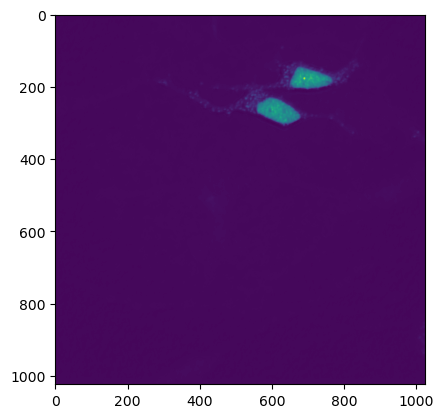

In [183]:
plt.imshow(images[3])

In [156]:
# Import masks

mask_cell_dir = '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Cell'
mask_cell_path = os.path.join(mask_cell_dir,'*.tif') 
mask_cell_files = glob.glob(mask_cell_path)

mask_nucleus_dir = '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Nucleus'
mask_nucleus_path = os.path.join(mask_nucleus_dir,'*.tif') 
mask_nucleus_files = glob.glob(mask_nucleus_path)


In [157]:
# Sorts images in list alphabetically

mask_cell_sorted = np.sort(mask_cell_files)
mask_nucleus_sorted = np.sort(mask_nucleus_files)

mask_nucleus_sorted

array(['/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Nucleus/MAX_1-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_nucleus_Object Identities.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Nucleus/MAX_2-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_nucleus_Object Identities.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Nucleus/MAX_3-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_nucleus_Object Identities.tif',
       '/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Nucleus/MAX_4-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_

In [158]:
# Read images into list

mask_cell = []
mask_nucleus = []

for file in mask_cell_sorted:
    image = imread(file)
    mask_cell.append(image)

for file in mask_nucleus_sorted:
    image = imread(file)
    mask_nucleus.append(image)

In [159]:
np.unique(mask_cell[3])

array([0, 1], dtype=uint32)

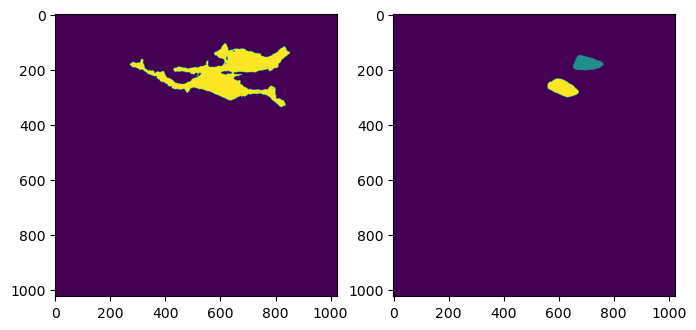

In [160]:
# Plot whole cell and nucleus mask side by side

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_cell[3])
ax[1].imshow(mask_nucleus[3])

### Watershedding from nucleus to separate cell masks

In [161]:
# Watershed using the nucleus as see to separate the overlapping cell masks

mask_label=[]
distance_maps = []

for cell, nucleus in zip(mask_cell, mask_nucleus):
    
    # 1. Smooth the distance transform of the cell mask
    distance_map = ndi.distance_transform_edt(cell)
    smoothed_distance_map = filters.gaussian(distance_map, sigma=1)
    distance_maps.append(smoothed_distance_map)

    # 2. Use the nuclei labels as markers
    markers = measure.label(nucleus)

    # 3. Apply the watershed algorithm
    labels = segmentation.watershed(-smoothed_distance_map, markers, mask=cell)
    mask_label.append(labels)


In [162]:
np.unique(mask_label[3])

array([0, 1, 2, 3, 4], dtype=int32)

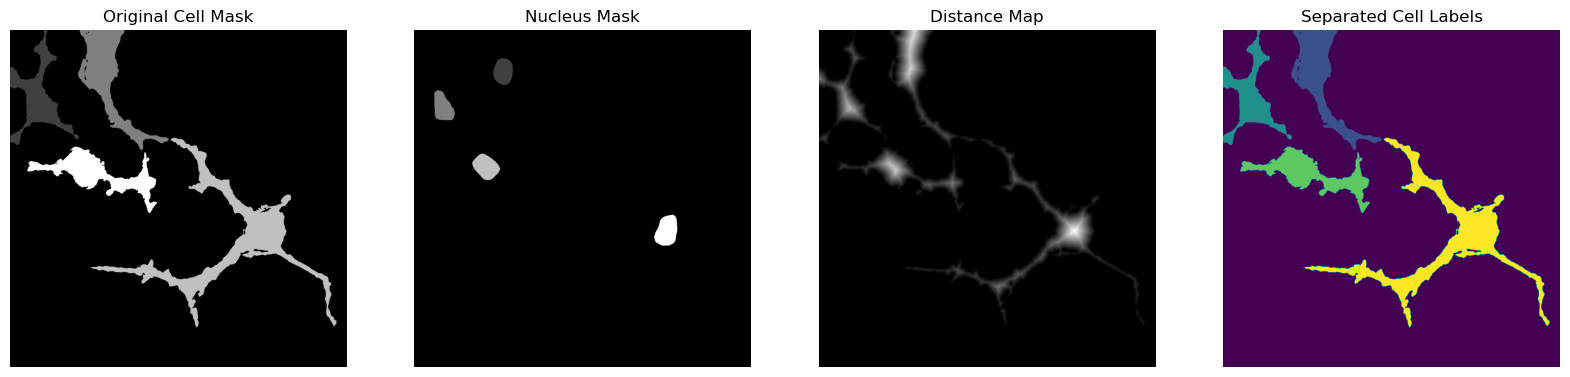

In [163]:
# Plotting the results including the distance map
fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(mask_cell[2], cmap='gray')
ax[0].set_title('Original Cell Mask')

ax[1].imshow(mask_nucleus[2], cmap='gray')
ax[1].set_title('Nucleus Mask')

ax[2].imshow(distance_maps[2], cmap='gray')
ax[2].set_title('Distance Map')

ax[3].imshow(mask_label[2])
ax[3].set_title('Separated Cell Labels')

for a in ax:
    a.axis('off')

plt.show()

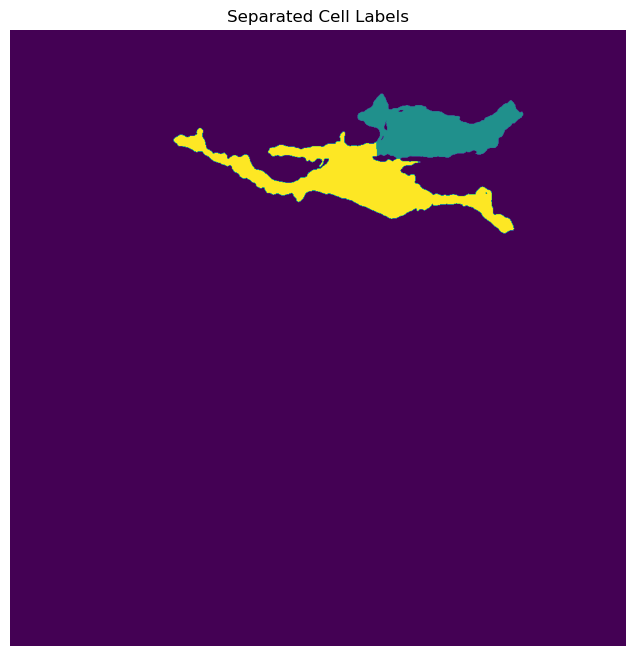

In [164]:
# Plotting only the separated cell labels
plt.figure(figsize=(8, 8))
plt.imshow(mask_label[3])
plt.title('Separated Cell Labels')
plt.axis('off')
plt.show()

In [165]:
print(np.unique(mask_label[3]))
print(np.unique(mask_nucleus[3]))

[0 1 2]
[0 1 2]


### Creating cytoplasm mask

In [166]:
# To match intensity values (= labels) of ROIs in nucleus image to intensity values of ROIs in whole cell image

for nucleus_image, cell_image in zip(mask_nucleus, mask_label):
    # Create a dictionary to store coordinates and corresponding intensity values from mask_cell
    coordinates_intensity = {}

    # Store coordinates and intensity values from cell_image in the dictionary
    for cell_label in regionprops(cell_image):
        for coord in cell_label.coords:
            coordinates_intensity[tuple(coord)] = cell_image[coord[0], coord[1]]

    # Update nucleus_image based on the mapped coordinates and intensity values
    for nucleus_label in regionprops(nucleus_image):
        for coord in nucleus_label.coords:
            if tuple(coord) in coordinates_intensity:
                nucleus_image[coord[0], coord[1]] = coordinates_intensity[tuple(coord)]

In [167]:
print(np.unique(mask_label[3]))
print(np.unique(mask_nucleus[3]))

[0 1 2]
[0 1 2]


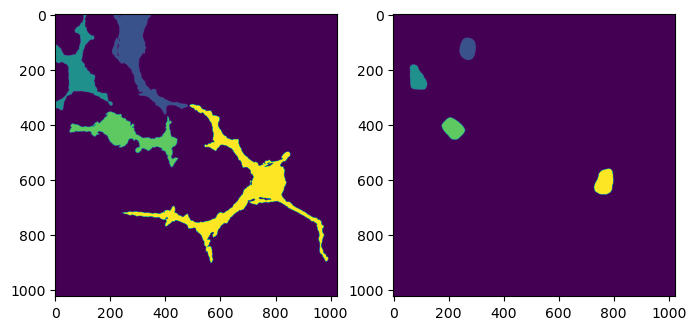

In [168]:
# Plot results of label matching

fig, ax = plt.subplots(1, 2, figsize = (8,4))
ax[0].imshow(mask_label[2])
ax[1].imshow(mask_nucleus[2])

In [169]:
# Substract nucleus mask from cell mask and store as binary cytoplasm mask

def subtract_nucleus_from_cell(cell_mask, nucleus_mask):
    """
    Subtract the nucleus mask from the cell mask and return the cytoplasm mask.
    """
    # Create a copy of the cell mask to modify
    cytoplasm_mask = cell_mask.copy()
    
    # Set the areas where nucleus label is present to 0 in the cell mask
    cytoplasm_mask[nucleus_mask > 0] = 0
    
    return cytoplasm_mask

# List to store cytoplasm masks
mask_cytoplasm = []

for cell, nucleus in zip(mask_label, mask_nucleus):
    # Subtract nucleus mask from cell mask
    cytoplasm_mask = subtract_nucleus_from_cell(cell, nucleus)
    
    mask_cytoplasm.append(cytoplasm_mask)

# Check results
for i, cytoplasm in enumerate(mask_cytoplasm):
    print(f"Unique values in cytoplasm mask {i}: {np.unique(cytoplasm)}")


Unique values in cytoplasm mask 0: [0 1]
Unique values in cytoplasm mask 1: [0 1]
Unique values in cytoplasm mask 2: [0 1 2 3 4]
Unique values in cytoplasm mask 3: [0 1 2]
Unique values in cytoplasm mask 4: [0 1]


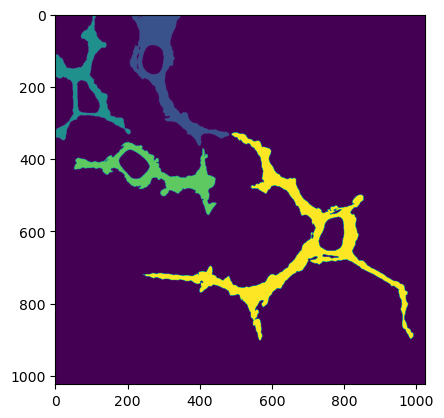

In [171]:
# Plot binary cytoplasm mask

plt.imshow(mask_cytoplasm[2])

### Mask corrections with Napari for overlapping cells

Click pasteur pipette to pick a label. Use paint brush to draw a line to sperate two labels. Fill entire area with according label with fill bucket option. To create background, select label 0 and use the paint brush to draw and bucket to fill up.

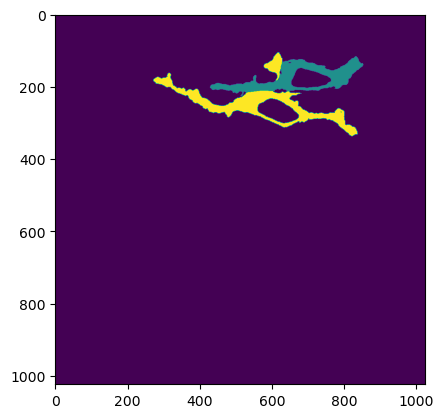

In [179]:
# Create copies of cytoplasm masks for manipulation in Napari

mask_cytoplasm_copy = mask_cytoplasm.copy()
plt.imshow(mask_cytoplasm_copy[3])

In [ ]:
# Initializes Napari viewer

viewer = napari.Viewer()

In [189]:
# Adds images to Napari viewer

for i, img in enumerate(images):
    layer_name = f'image_{i}'  # Dynamically name each layer
    viewer.add_image(img, name=layer_name)

In [190]:
# Adds masks to Napari viewer

for i, img in enumerate(mask_cytoplasm_copy):
    layer_name = f'segmentation_{i}'  # Dynamically name each layer
    labels_layer = viewer.add_labels(img, name=layer_name, opacity=0.6)

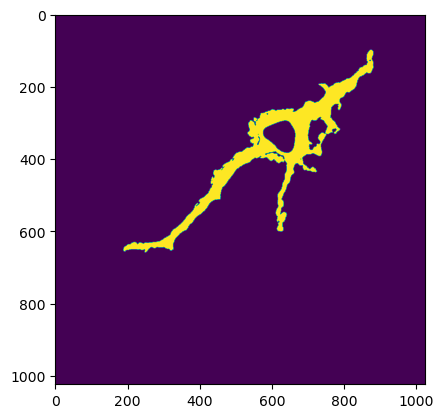

In [197]:
plt.imshow(mask_cytoplasm_copy[4])

### Saving finished masks

In [198]:
# Save cytoplasm masks

#mask_cytoplasm_dir = r'/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Cytoplasm'


In [199]:
# Save mask images

# Save mask images
for img, tiff_file in zip(mask_cytoplasm_copy, mask_cell_files):
    
    # Extract the original file name without the extension
    file_name = os.path.splitext(os.path.basename(tiff_file))[0]
    
    # Replace spaces with underscores
    file_name = file_name.replace(' ', '_')
    
    print(file_name)
    
    # Define the output file path
    output_file = os.path.join(mask_cytoplasm_dir, file_name + '.tif')
    print(output_file)
    
    # Save the manipulated image as a TIFF
    tf.imwrite(output_file, img)

MAX_4-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_cell_Object_Identities
/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Cytoplasm/MAX_4-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_cell_Object_Identities.tif
MAX_2-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_cell_Object_Identities
/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Cytoplasm/MAX_2-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_cell_Object_Identities.tif
MAX_1-2_5z-1-0_561-30-100ms-1000g_488-5-50ms-200g_1_w1conf561_zproject_denoised_cell_Object_Identities
/Users/abamford/Documents/ChaoLab/Imaging/Processed/20240604/Pre-patterning_D5/ACTB_well1/Max_projections_denoised2/00_Object_identities/Cytoplasm/MAX_1-2_5z-1-0_561-30-100ms-1000g_48

: 